<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
from collections import OrderedDict
import anndata as ad
import scanpy as sc
from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# Idempotency

Some datasets of use:
- tiny mouse heart dataset from CellBender (CellBender/examples/remove_background/generate_tiny_10x_dataset.py): https://www.10xgenomics.com/resources/datasets/10-k-heart-cells-from-an-e-18-mouse-v-3-chemistry-3-standard-3-0-0 

- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k?

In [3]:
dataset_name = "pbmc8k"  # options: pbmc8k
alternative_tools = ["cellbender", "soupx", "decontx", "scar", "cellsweep_no_empties"]  # ["cellbender", "soupx", "decontx", "scar", "cellsweep_no_empties"]
iterations = 4
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
scar_env = "/home/jrich/miniconda3/envs/scar"  # installing scAR: git clone https://github.com/Novartis/scar.git; cd scar; conda env create -f scar-cpu.yml (or scar-gpu.yml)
use_cuda = False
threads = 32
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [4]:
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name, "idempotency")
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name, "idempotency")
os.makedirs(out_dir, exist_ok=True)

if dataset_name == "pbmc8k":
    adata_path_raw = f"{data_dir}/pbmc8k_raw_gene_bc_matrices_h5.h5"
    sequencing_technology = "10XV2"
    model_pkl = "Immune_All_High.pkl"  # path, filename, or url for celltypist model pkl file
    expected_cells = 8381

    if not os.path.exists(adata_path_raw):
        !wget -O {adata_path_raw} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices_h5.h5

    matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
    os.makedirs(matrix_tar_files_dir, exist_ok=True)
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "GRCh38")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "GRCh38")
    if not os.path.exists(raw_tar_file_dir):
        raw_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_raw_gene_bc_matrices.tar.gz")
        !wget -O {raw_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_raw_gene_bc_matrices.tar.gz
        !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    if not os.path.exists(filtered_tar_file_dir):
        filtered_tar_path = os.path.join(matrix_tar_files_dir, "pbmc8k_filtered_gene_bc_matrices.tar.gz")
        !wget -O {filtered_tar_path} https://cf.10xgenomics.com/samples/cell-exp/2.1.0/pbmc8k/pbmc8k_filtered_gene_bc_matrices.tar.gz
        !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}
else:
    raise ValueError(f"Dataset name {dataset_name} not recognized.")

min_genes = 0
min_cells = 0
umi_top_percentile_to_remove = 5
unique_genes_top_percentile_to_remove = 5
mt_gene_percentile_to_remove = 10
max_mt_percentage = None
n_top_genes = 2000
n_pcs = 25
n_neighbors = 20
leiden_resolution = 1.0

adatas_cellsweep = None
adatas_cellbender = None
adatas_soupx = None
adatas_decontx = None
adatas_scar = None

tools = ["cellsweep"] + alternative_tools

## Raw

In [5]:
adata_raw = cs_utils.load_adata(adata_path_raw, verbose=verbose)
adata_raw.var_names_make_unique()

adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", expected_cells=expected_cells, verbose=verbose)  # adds adata.obs["is_empty"]

13:16:40 - INFO - Loading adata from '/home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/idempotency/pbmc8k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## cellsweep

In [6]:
adata = adata_raw.copy()

adatas_cellsweep = [adata]
for it in range(1, iterations+1):
    print(f"Iteration {it} / {iterations}")
    adata_path_cellsweep = os.path.join(data_dir, f"cellsweep_iteration{it}.h5ad")
    cellsweep_log_file = os.path.join(data_dir, f"cellsweep_iteration{it}.log")
    if not os.path.exists(adata_path_cellsweep) or overwrite:
        if "celltype" not in adata.obs.columns:
            adata = cs_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
        adata = denoise_count_matrix(adata, adata_out=adata_path_cellsweep, max_iter=500, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellsweep_log_file)
    else:
        adata = ad.read_h5ad(adata_path_cellsweep)
    adata_filtered = adata[~adata.obs["is_empty"]].copy()
    adata_filtered.var_names_make_unique()
    adatas_cellsweep.append(adata_filtered)

Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4
Iteration 4 / 4


# cellsweep no empties

In [7]:
adatas_cellsweep_no_empties = None

if "cellsweep_no_empties" in tools:
    adata = adata_raw.copy()
    adata = adata[~adata.obs["is_empty"]].copy()

    adatas_cellsweep_no_empties = [adata]
    for it in range(1, iterations+1):
        print(f"Iteration {it} / {iterations}")
        adata_path_cellsweep = os.path.join(data_dir, f"cellsweep_no_empties_iteration{it}.h5ad")
        cellsweep_log_file = os.path.join(data_dir, f"cellsweep_no_empties_iteration{it}.log")
        if not os.path.exists(adata_path_cellsweep) or overwrite:
            if "celltype" not in adata.obs.columns:
                adata = cs_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, verbose=verbose)
            adata = denoise_count_matrix(adata, adata_out=adata_path_cellsweep, max_iter=500, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellsweep_log_file)
        else:
            adata = ad.read_h5ad(adata_path_cellsweep)
        adata_filtered = adata[~adata.obs["is_empty"]].copy()
        adata_filtered.var_names_make_unique()
        adatas_cellsweep_no_empties.append(adata_filtered)

13:16:52 - INFO - Filtering empty droplets using column 'is_empty' in adata.obs. If this column is not present, it will be inferred using method 'celltypist' with umi_cutoff=None and expected_cells=8381.
13:16:52 - INFO - Running cell type annotation using CellTypist with model_pkl=Immune_All_High.pkl. This may take some time depending on the size of the dataset and the model used.
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
👉 Detailed model information can be found at `https://www.celltypist.org/models`
13:16:52 - INFO - 'counts' layer not found in adata_real. Creating 'counts' layer from adata_real.X and normalizing total counts to 1e4.


Iteration 1 / 4


13:16:53 - INFO - 'log1p' not found in adata_real.uns. Applying log1p transformation to adata_real.X and storing in 'log1p' layer.
🔬 Input data has 8381 cells and 33694 genes
🔗 Matching reference genes in the model
🧬 5656 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!
13:17:30 - INFO - Starting cellsweep denoising at 2026-02-10 13:17:30, cellsweep version 0.1.0
13:17:30 - INFO - Inferring celltype profiles.
13:17:30 - WARNING - 0 empty barcodes found. Setting freeze_ambient_profile=False, as at least 30 empty barcodes are required to keep this setting True. Ambient profile estimation may be unreliable.
13:17:30 - INFO - Number of celltypes: 7
13:17:30 - DEBUG - Number of parameters in the cellsweep model: 244,247 (u: 7, alpha: 8,381, beta: 1, p_k

Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/idempotency/cellsweep_no_empties_iteration1.log


13:17:30 - INFO - Performing Sparse EM with 32 Numba thread(s)
13:17:35 - INFO - EM Iter   1: ll=-31766.622 log_delta_p=inf min_alpha=0.7189 mean_alpha=0.8842 median_alpha=0.8922 max_alpha=0.9160 beta=0.098989
13:17:39 - INFO - EM Iter   2: ll=-31663.901 log_delta_p=inf min_alpha=0.3564 mean_alpha=0.8580 median_alpha=0.8799 max_alpha=0.9348 beta=0.096778
13:17:39 - INFO - EM Iter   3: ll=-31671.379 log_delta_p=-1.2490 min_alpha=0.1953 mean_alpha=0.8333 median_alpha=0.8645 max_alpha=0.9512 beta=0.096986
13:17:39 - INFO - EM Iter   4: ll=-31687.739 log_delta_p=-1.7480 min_alpha=0.1181 mean_alpha=0.8049 median_alpha=0.8506 max_alpha=0.9626 beta=0.099438
13:17:39 - INFO - EM Iter   5: ll=-31597.960 log_delta_p=-1.9238 min_alpha=0.0764 mean_alpha=0.7779 median_alpha=0.8387 max_alpha=0.9711 beta=0.100343
13:17:39 - INFO - EM Iter   6: ll=-31501.620 log_delta_p=-2.3042 min_alpha=0.0539 mean_alpha=0.7585 median_alpha=0.8297 max_alpha=0.9778 beta=0.098952
13:17:39 - INFO - EM Iter   7: ll=-3145

...

13:18:06 - INFO - EM Iter   1: ll=-24601.270 log_delta_p=inf min_alpha=0.7159 mean_alpha=0.8819 median_alpha=0.8916 max_alpha=0.9375 beta=0.099321
13:18:06 - INFO - EM Iter   2: ll=-24482.279 log_delta_p=inf min_alpha=0.3445 mean_alpha=0.8497 median_alpha=0.8745 max_alpha=0.9696 beta=0.096458
13:18:06 - INFO - EM Iter   3: ll=-24475.028 log_delta_p=-1.2117 min_alpha=0.1863 mean_alpha=0.8193 median_alpha=0.8553 max_alpha=0.9903 beta=0.096272
13:18:06 - INFO - EM Iter   4: ll=-24500.697 log_delta_p=-1.6189 min_alpha=0.1092 mean_alpha=0.7834 median_alpha=0.8390 max_alpha=0.9965 beta=0.099781
13:18:06 - INFO - EM Iter   5: ll=-24404.965 log_delta_p=-1.7301 min_alpha=0.0681 mean_alpha=0.7494 median_alpha=0.8244 max_alpha=0.9985 beta=0.101006
13:18:06 - INFO - EM Iter   6: ll=-24299.545 log_delta_p=-2.1721 min_alpha=0.0465 mean_alpha=0.7253 median_alpha=0.8138 max_alpha=0.9994 beta=0.098800
13:18:06 - INFO - EM Iter   7: ll=-24252.845 log_delta_p=-2.5114 min_alpha=0.0340 mean_alpha=0.7094 me

Iteration 3 / 4
Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/idempotency/cellsweep_no_empties_iteration3.log


13:18:29 - INFO - EM Iter   1: ll=-15601.017 log_delta_p=inf min_alpha=0.0005 mean_alpha=0.8801 median_alpha=0.8913 max_alpha=0.9265 beta=0.104652
13:18:29 - INFO - EM Iter   2: ll=-15479.799 log_delta_p=inf min_alpha=0.0000 mean_alpha=0.8473 median_alpha=0.8699 max_alpha=0.9579 beta=0.102751
13:18:29 - INFO - EM Iter   3: ll=-15472.524 log_delta_p=-1.3175 min_alpha=0.0000 mean_alpha=0.8143 median_alpha=0.8347 max_alpha=0.9769 beta=0.103390
13:18:29 - INFO - EM Iter   4: ll=-15510.614 log_delta_p=-1.6116 min_alpha=0.0000 mean_alpha=0.7749 median_alpha=0.7977 max_alpha=0.9872 beta=0.108978
13:18:29 - INFO - EM Iter   5: ll=-15452.775 log_delta_p=-1.6513 min_alpha=0.0000 mean_alpha=0.7343 median_alpha=0.7580 max_alpha=0.9928 beta=0.111440
13:18:29 - INFO - EM Iter   6: ll=-15385.658 log_delta_p=-2.2158 min_alpha=0.0000 mean_alpha=0.6988 median_alpha=0.7206 max_alpha=0.9962 beta=0.109460
13:18:30 - INFO - EM Iter   7: ll=-15352.921 log_delta_p=-2.5873 min_alpha=0.0000 mean_alpha=0.6681 me

Iteration 4 / 4
Logging to /home/jrich/Desktop/cellsweep/notebooks/data/pbmc8k/idempotency/cellsweep_no_empties_iteration4.log


13:18:56 - INFO - EM Iter   1: ll=-15020.478 log_delta_p=inf min_alpha=0.0000 mean_alpha=0.8592 median_alpha=0.8908 max_alpha=0.8988 beta=0.105692
13:18:56 - INFO - EM Iter   2: ll=-14897.418 log_delta_p=inf min_alpha=0.0000 mean_alpha=0.8251 median_alpha=0.8673 max_alpha=0.9003 beta=0.104139
13:18:56 - INFO - EM Iter   3: ll=-14889.002 log_delta_p=-1.3229 min_alpha=0.0000 mean_alpha=0.7910 median_alpha=0.8300 max_alpha=0.8987 beta=0.104998
13:18:56 - INFO - EM Iter   4: ll=-14928.327 log_delta_p=-1.6049 min_alpha=0.0000 mean_alpha=0.7501 median_alpha=0.7901 max_alpha=0.8955 beta=0.111066
13:18:56 - INFO - EM Iter   5: ll=-14871.646 log_delta_p=-1.6349 min_alpha=0.0000 mean_alpha=0.7076 median_alpha=0.7467 max_alpha=0.8956 beta=0.113811
13:18:56 - INFO - EM Iter   6: ll=-14806.540 log_delta_p=-2.2269 min_alpha=0.0000 mean_alpha=0.6699 median_alpha=0.7056 max_alpha=0.8988 beta=0.111925
13:18:56 - INFO - EM Iter   7: ll=-14775.084 log_delta_p=-2.5794 min_alpha=0.0000 mean_alpha=0.6366 me

## CellBender (v0.3.0)

In [7]:
if "cellbender" in alternative_tools:    
    adatas_cellbender = [adata_raw]
    runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
    gpus = "--gpus all" if use_cuda else ""

    input_path = adata_path_raw.replace(f"{cellsweep_dir}/notebooks/data", "/data")
    for it in range(1, iterations+1):
        print(f"Iteration {it} / {iterations}")
        output_path_local = os.path.join(data_dir, f"cellbender_iteration{it}.h5")
        adata_path_cellbender_filtered = output_path_local.replace(".h5", "_filtered.h5")
        output_path = output_path_local.replace(f"{cellsweep_dir}/notebooks/data", "/data")
        if not os.path.exists(output_path_local) or overwrite:
            !{docker} run --rm {gpus} -v {cellsweep_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
                cellbender remove-background \
                --input {input_path} \
                --output {output_path} \
                --epochs 150 \
                --fpr 0.01 \
                --model full \
                {runtime}
        input_path = output_path
        adata = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
        adata.var_names_make_unique()
        adatas_cellbender.append(adata)

Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4
Iteration 4 / 4


## SoupX (v1.6.2)

In [8]:
if "soupx" in alternative_tools:
    adata_soupx_obs_csv = f"{data_dir}/{dataset_name}_soupx_obs.csv"
    if not os.path.exists(adata_soupx_obs_csv) or overwrite:
        adata_soupx_tmp = cs_utils.load_adata(filtered_tar_file_dir)
        adata_soupx_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
        adata_soupx_tmp.obs[["leiden"]].to_csv(adata_soupx_obs_csv)

    matrix_tar_files_dir_soupx = matrix_tar_files_dir
    # raw_tar_file_dir_soupx = raw_tar_file_dir
    # filtered_tar_file_dir_soupx = filtered_tar_file_dir
    adatas_soupx = [adata_raw]
    adatas_soupx_concat = [adata_raw]
    for it in range(1, iterations+1):
        print(f"Iteration {it} / {iterations}")
        soupx_out_prefix = os.path.join(data_dir, f"soupX_iteration{it}")
        if not os.path.exists(f"{soupx_out_prefix}.mtx") or overwrite:
            !{docker} run --rm \
                -w /home/ruser/work \
                -v {cellsweep_dir}:{rver_docker_workspace} \
                josephrich98/cellsweep_tutorials:soupx.0.1.0 \
                Rscript {rver_docker_workspace}/scripts/run_soupx.R \
                    {matrix_tar_files_dir_soupx.replace(cellsweep_dir, rver_docker_workspace)} \
                    {adata_soupx_obs_csv.replace(cellsweep_dir, rver_docker_workspace)} \
                    {soupx_out_prefix.replace(cellsweep_dir, rver_docker_workspace)} \
                    leiden
            
        adata_soupx = cs_utils.load_adata(soupx_out_prefix)
        adata_soupx.var_names_make_unique()
        adatas_soupx.append(adata_soupx)

        matrix_tar_files_dir_soupx = f"{soupx_out_prefix}_matrix_tar_files"
        # raw_tar_file_dir_soupx = os.path.join(matrix_tar_files_dir_soupx, "raw_gene_bc_matrices", "GRCh38")
        # filtered_tar_file_dir_soupx = os.path.join(matrix_tar_files_dir_soupx, "filtered_gene_bc_matrices", "GRCh38")
        
        # merge adatas_soupx_concat[it-1] into it, and fill NaN with True
        adata_soupx.obs["is_empty"] = False
        adata_prev = adatas_soupx_concat[it-1]
        cells_prev = set(adata_prev.obs_names)  # 1. find missing cells
        cells_curr = set(adata_soupx.obs_names)
        missing_cells = list(cells_prev - cells_curr)
        adata_missing = adata_prev[missing_cells].copy()  # 2. subset missing cells
        adata_missing.obs["is_empty"] = True
        adata_soupx = sc.concat([adata_soupx, adata_missing], join="outer", merge="unique", label=None, index_unique=None)  # 3. concat
        adatas_soupx_concat.append(adata_soupx)
        if not os.path.exists(matrix_tar_files_dir_soupx) or overwrite:
            _ = cs_utils.write_10x_like(adata_soupx, matrix_tar_files_dir_soupx, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="GRCh38", write_raw=True, write_filtered=True)

Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4
Iteration 4 / 4


## DecontX (v1.8.0)

In [9]:
if "decontx" in alternative_tools:
    matrix_tar_files_dir_decontx = matrix_tar_files_dir
    raw_tar_file_dir_decontx = raw_tar_file_dir
    filtered_tar_file_dir_decontx = filtered_tar_file_dir
    adatas_decontx = [adata_raw]
    adatas_decontx_concat = [adata_raw]
    for it in range(1, iterations+1):
        print(f"Iteration {it} / {iterations}")
        decontx_out_prefix = os.path.join(data_dir, f"decontx_iteration{it}")
        if not os.path.exists(f"{decontx_out_prefix}.mtx") or overwrite:
            !{docker} run --rm \
                -w /home/ruser/work \
                -v {cellsweep_dir}:{rver_docker_workspace} \
                josephrich98/cellsweep_tutorials:decontx.0.1.0 \
                Rscript {rver_docker_workspace}/scripts/run_decontx.R \
                    {raw_tar_file_dir_decontx.replace(cellsweep_dir, rver_docker_workspace)} \
                    {filtered_tar_file_dir_decontx.replace(cellsweep_dir, rver_docker_workspace)} \
                    {sequencing_technology} \
                    {decontx_out_prefix.replace(cellsweep_dir, rver_docker_workspace)} \
                    --dont_prepend_sample_to_barcodes
            
        adata_decontx = cs_utils.load_adata(decontx_out_prefix)
        adata_decontx.var_names_make_unique()
        adatas_decontx.append(adata_decontx)

        matrix_tar_files_dir_decontx = f"{decontx_out_prefix}_matrix_tar_files"
        raw_tar_file_dir_decontx = os.path.join(matrix_tar_files_dir_decontx, "raw_gene_bc_matrices", "GRCh38")
        filtered_tar_file_dir_decontx = os.path.join(matrix_tar_files_dir_decontx, "filtered_gene_bc_matrices", "GRCh38")
        
        # merge adatas_decontx_concat[it-1] into it, and fill NaN with True
        adata_decontx.obs["is_empty"] = False
        adata_prev = adatas_decontx_concat[it-1]
        cells_prev = set(adata_prev.obs_names)  # 1. find missing cells
        cells_curr = set(adata_decontx.obs_names)
        missing_cells = list(cells_prev - cells_curr)
        adata_missing = adata_prev[missing_cells].copy()  # 2. subset missing cells
        adata_missing.obs["is_empty"] = True
        adata_decontx = sc.concat([adata_decontx, adata_missing], join="outer", merge="unique", label=None, index_unique=None)  # 3. concat
        adatas_decontx_concat.append(adata_decontx)
        
        if not os.path.exists(matrix_tar_files_dir_decontx) or overwrite:
            _ = cs_utils.write_10x_like(adata_decontx, matrix_tar_files_dir_decontx, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="GRCh38", write_raw=True, write_filtered=True)

Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4
Iteration 4 / 4


## scAR (v0.7.0)

In [10]:
%env MPLBACKEND=

if "scar" in alternative_tools:
    matrix_tar_files_dir_scar = matrix_tar_files_dir
    raw_tar_file_dir_scar = raw_tar_file_dir
    filtered_tar_file_dir_scar = filtered_tar_file_dir
    adatas_scar = [adata_raw]
    adatas_scar_concat = [adata_raw]
    for it in range(1, iterations+1):
        print(f"Iteration {it} / {iterations}")
        scar_out_prefix = os.path.join(data_dir, f"scar_iteration{it}")
        adata_path_scar = os.path.join(data_dir, f"scar_iteration{it}.h5ad")
        if not os.path.exists(adata_path_scar) or overwrite:
            runtime = "--cuda" if use_cuda else ""
            conda_run_flag = "-p" if "/" in scar_env else "-n"
            !conda run {conda_run_flag} {scar_env} \
                python {cellsweep_dir}/scripts/run_scar.py \
                -r {raw_tar_file_dir_scar} \
                -f {filtered_tar_file_dir_scar} \
                -o {adata_path_scar} \
                {runtime} \
                --epochs 200
            
        adata_scar = cs_utils.load_adata(adata_path_scar)
        adata_scar.var_names_make_unique()
        adatas_scar.append(adata_scar)

        matrix_tar_files_dir_scar = f"{scar_out_prefix}_matrix_tar_files"
        raw_tar_file_dir_scar = os.path.join(matrix_tar_files_dir_scar, "raw_gene_bc_matrices", "GRCh38")
        filtered_tar_file_dir_scar = os.path.join(matrix_tar_files_dir_scar, "filtered_gene_bc_matrices", "GRCh38")

        # merge adatas_scar_concat[it-1] into it, and fill NaN with True
        adata_scar.obs["is_empty"] = False
        adata_prev = adatas_scar_concat[it-1]
        cells_prev = set(adata_prev.obs_names)  # 1. find missing cells
        cells_curr = set(adata_scar.obs_names)
        missing_cells = list(cells_prev - cells_curr)
        adata_missing = adata_prev[missing_cells].copy()  # 2. subset missing cells
        adata_missing.obs["is_empty"] = True
        adata_scar = sc.concat([adata_scar, adata_missing], join="outer", merge="unique", label=None, index_unique=None)  # 3. concat
        adatas_scar_concat.append(adata_scar)
        
        if not os.path.exists(matrix_tar_files_dir_scar) or overwrite:
            _ = cs_utils.write_10x_like(adata_scar, matrix_tar_files_dir_scar, gzip_output=False, is_empty_col="is_empty", cluster_col=None, genome="GRCh38", write_raw=True, write_filtered=True)

env: MPLBACKEND=
Iteration 1 / 4
Iteration 2 / 4
Iteration 3 / 4
Iteration 4 / 4


# Analysis

In [ ]:
adatas_dict = OrderedDict(
    cellsweep=adatas_cellsweep,
    cellbender=adatas_cellbender if adatas_cellbender is not None else None,
    decontx=adatas_decontx if adatas_decontx is not None else None,
    scar=adatas_scar if adatas_scar is not None else None,
    soupx=adatas_soupx if adatas_soupx is not None else None,
    cellsweep_no_empties=None  #* treated specially
)

# # for debugging
# adatas_dict = {"cellsweep": adatas_cellsweep}
# alternative_tools = []

In [12]:
adatas_dict

OrderedDict([('cellsweep',
              [AnnData object with n_obs × n_vars = 737280 × 33694
                   obs: 'is_empty'
                   var: 'gene_ids',
               AnnData object with n_obs × n_vars = 8381 × 33694
                   obs: 'is_empty', 'celltype', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
                   var: 'gene_ids', 'ambient', 'ambient_hat'
                   uns: 'celltype_profile', 'celltype_names', 'celltype_profile_genes', 'p_hat', 'beta_hat', 'loglike'
                   layers: 'raw',
               AnnData object with n_obs × n_vars = 8381 × 33694
                   obs: 'is_empty', 'celltype', 'cell_ambient_fraction', 'alpha_hat', 'z_hat'
                   var: 'gene_ids', 'ambient', 'ambient_hat'
                   uns: 'celltype_profile', 'celltype_names', 'celltype_profile_genes', 'p_hat', 'beta_hat', 'loglike'
                   layers: 'raw',
               AnnData object with n_obs × n_vars = 8381 × 33694
                   obs: 

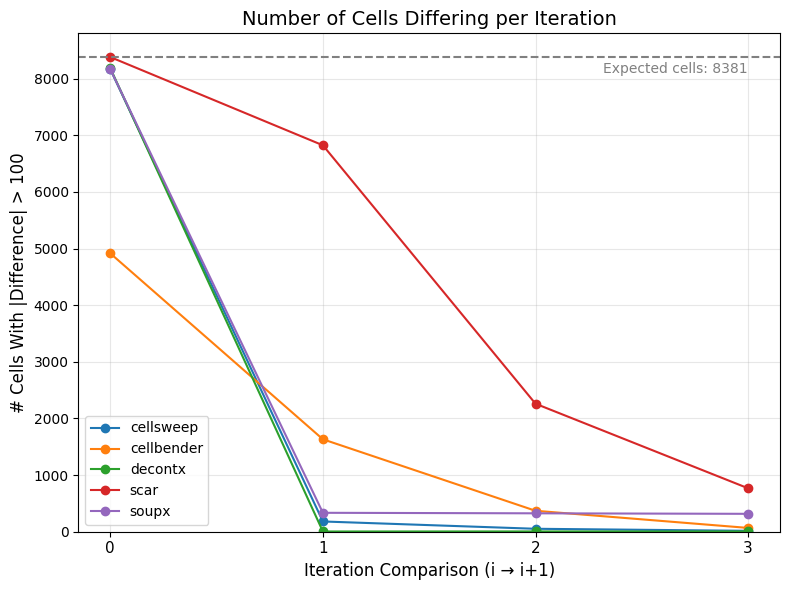

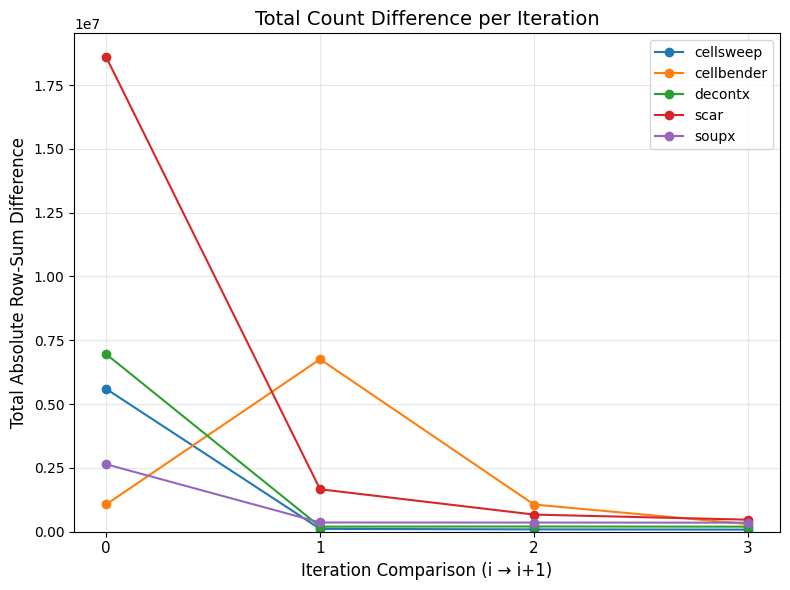

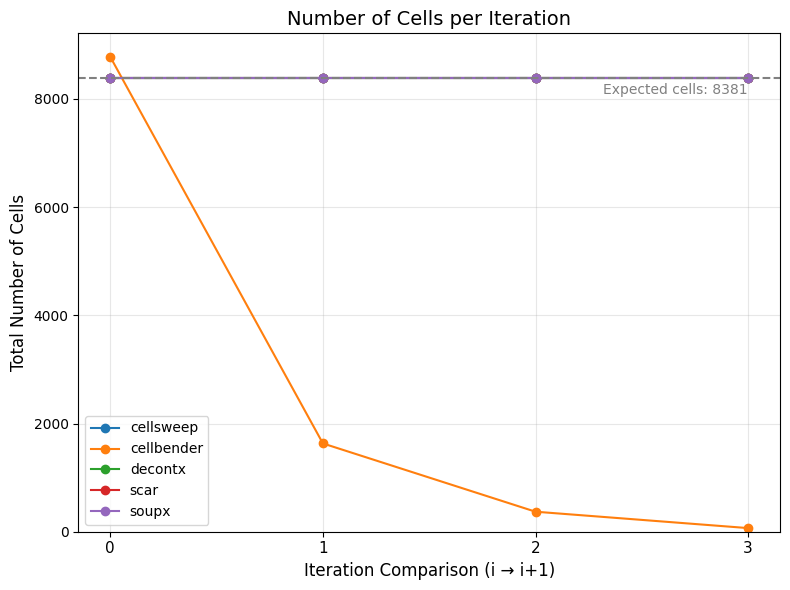

In [13]:
diff_counts = cs_utils.plot_iterative_difference_counts(adatas_dict, metric="cells", expected_cells=expected_cells, threshold=100, title="Number of Cells Differing per Iteration", out_path=os.path.join(out_dir, "diff_cells.png"))
diff_counts = cs_utils.plot_iterative_difference_counts(adatas_dict, metric="counts", title="Total Count Difference per Iteration", out_path=os.path.join(out_dir, "diff_counts.png"))
diff_counts = cs_utils.plot_iterative_difference_counts(adatas_dict, metric="number_of_cells", expected_cells=expected_cells, title="Number of Cells per Iteration", out_path=os.path.join(out_dir, "diff_number_of_cells.png"))

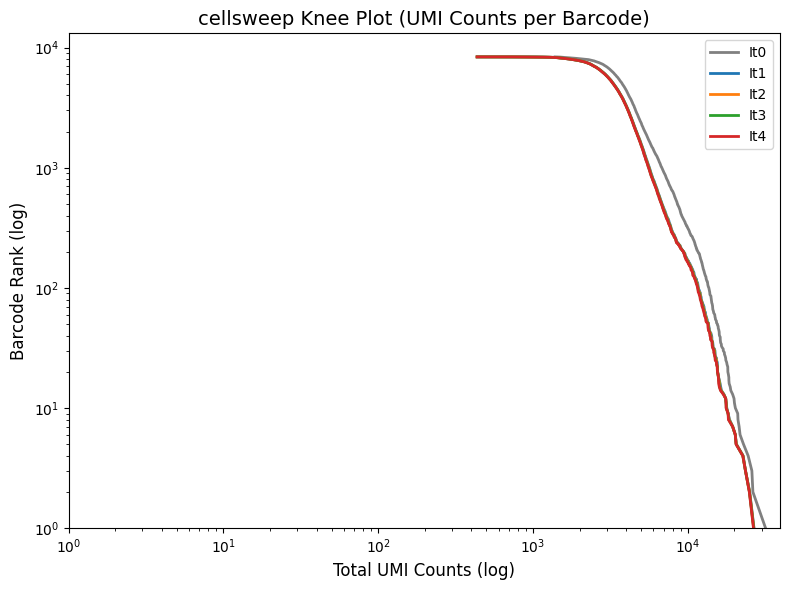

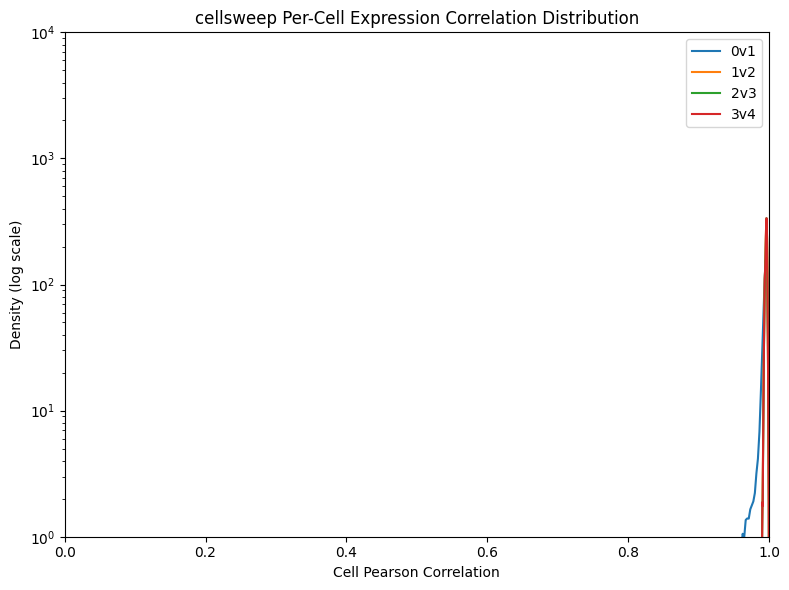

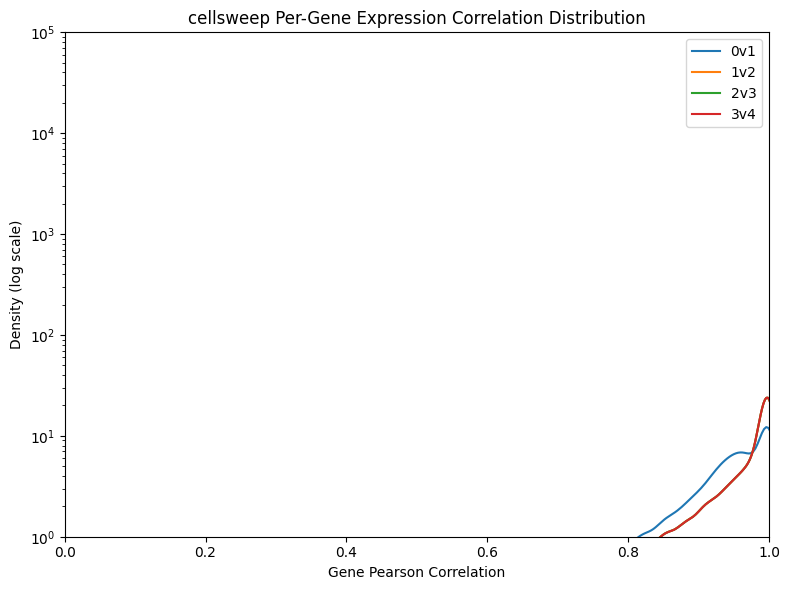

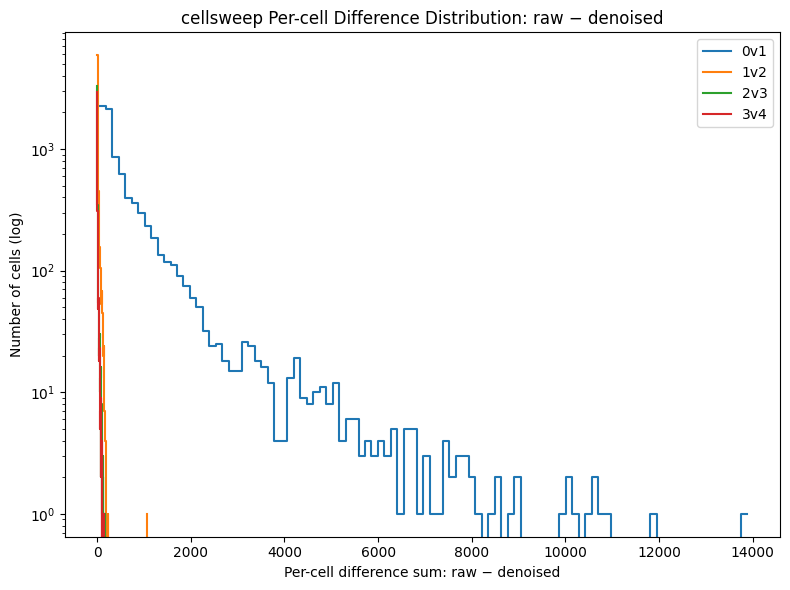

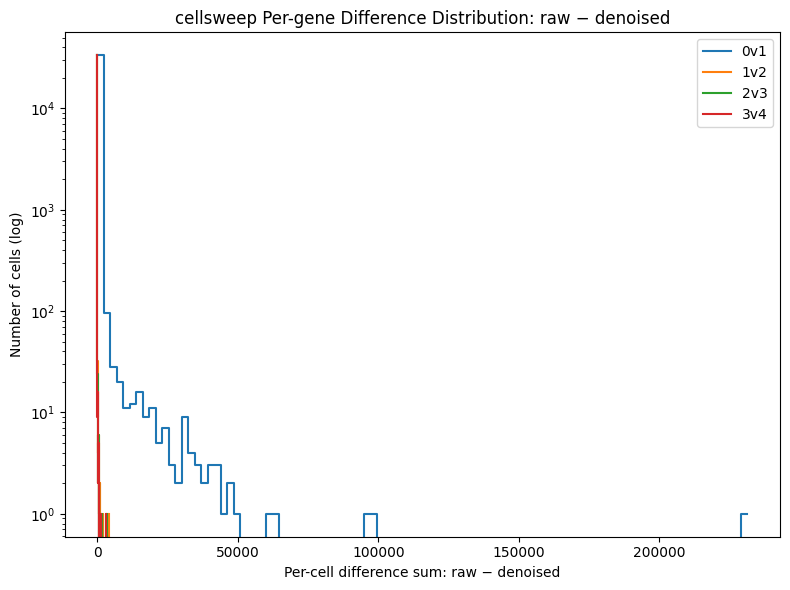

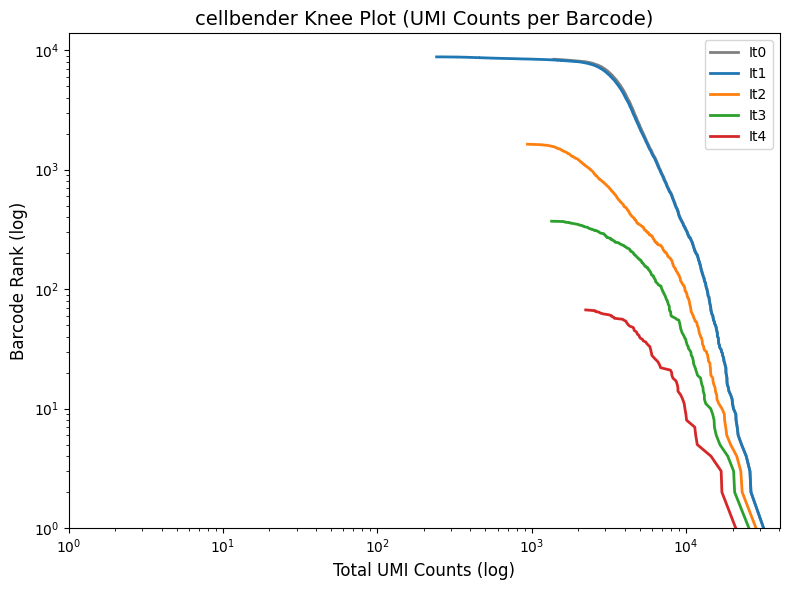

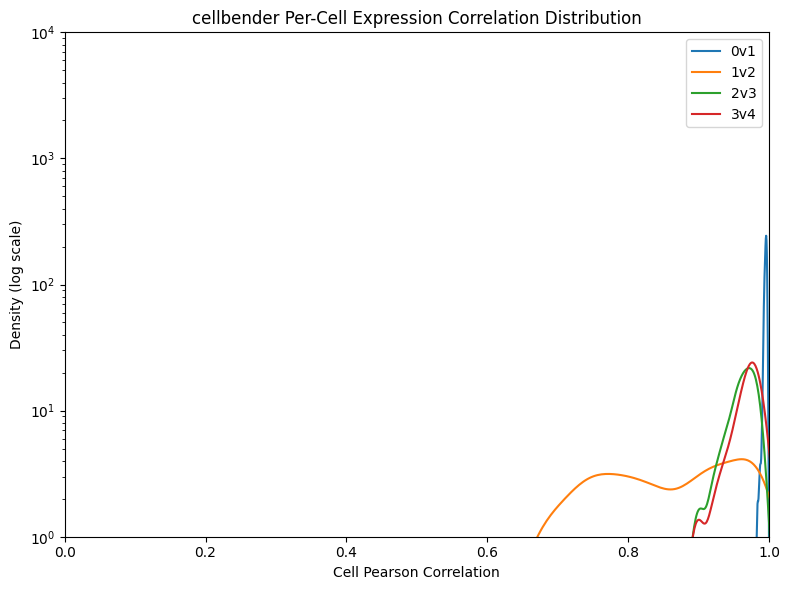

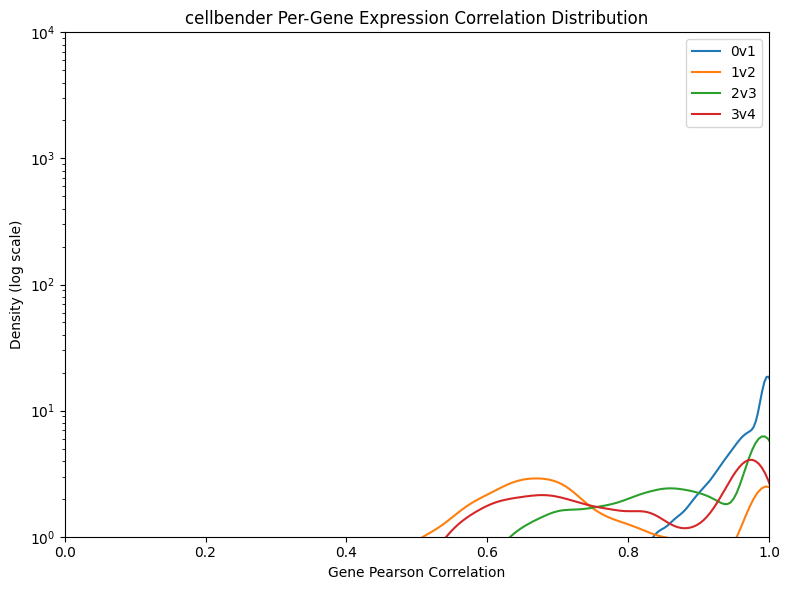

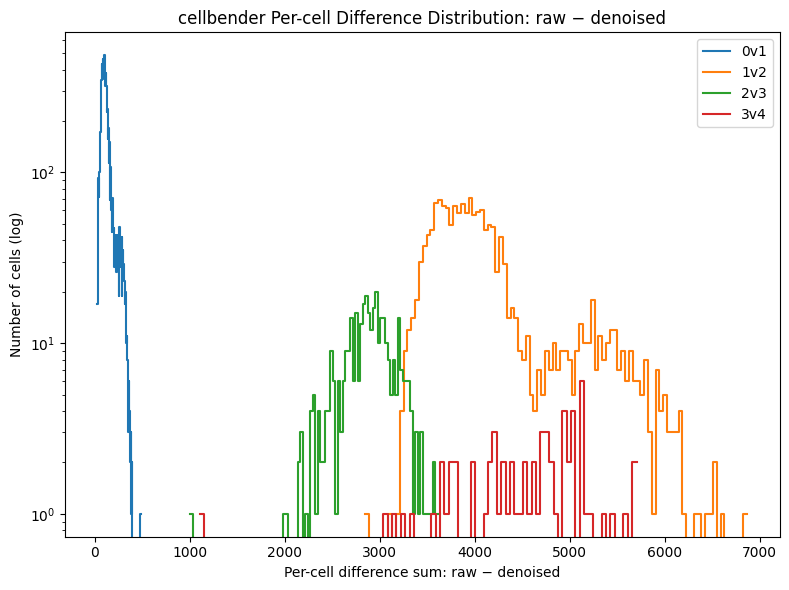

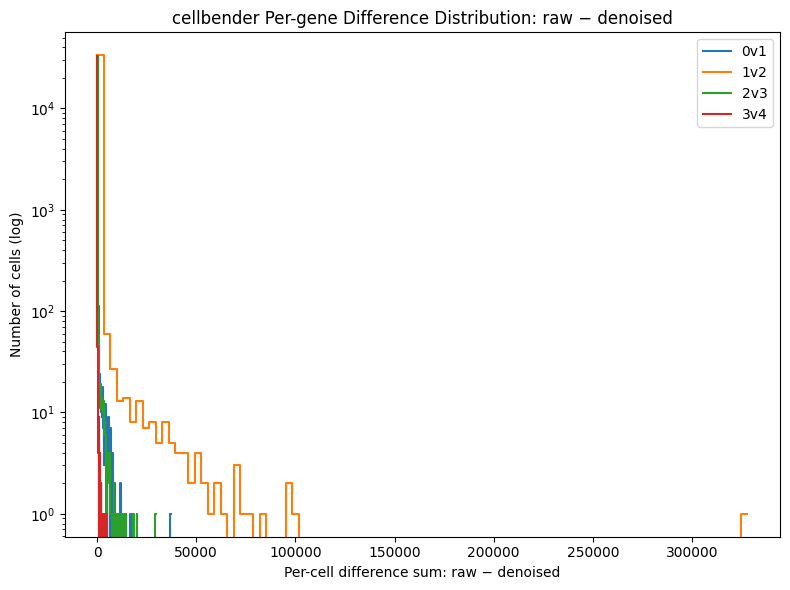

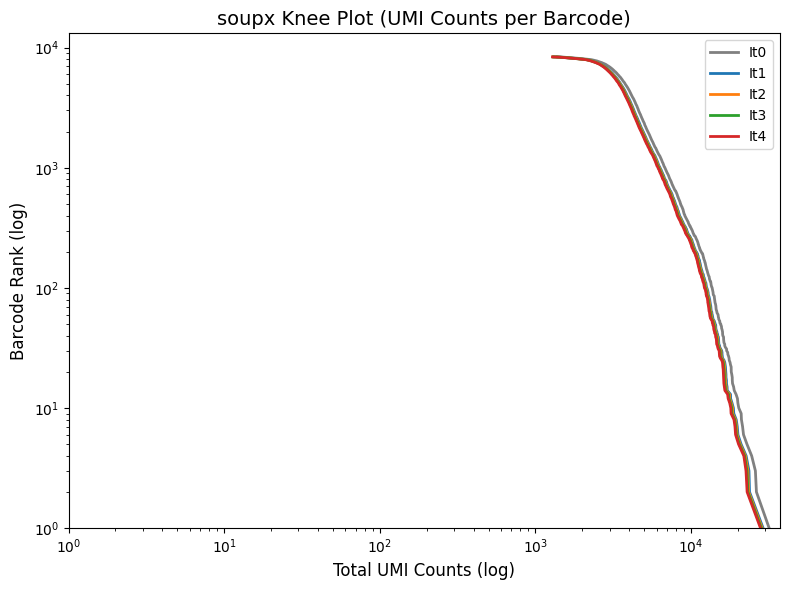

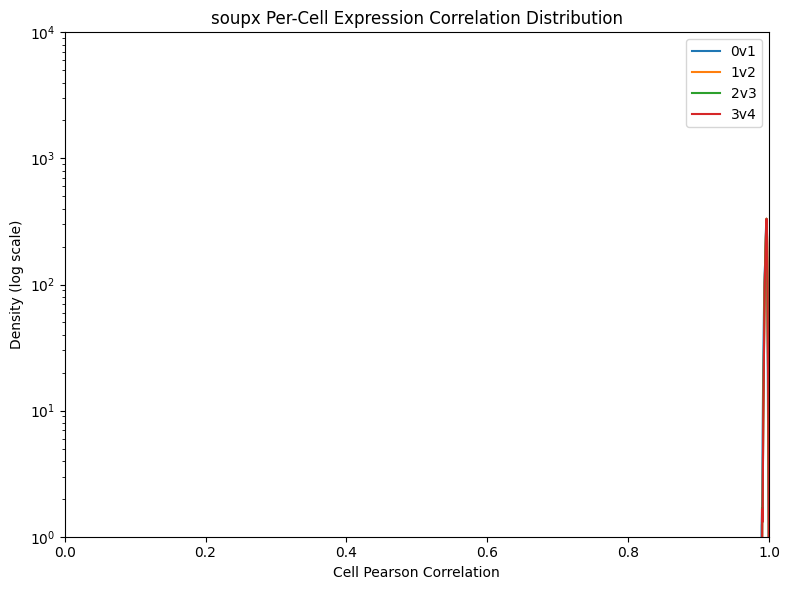

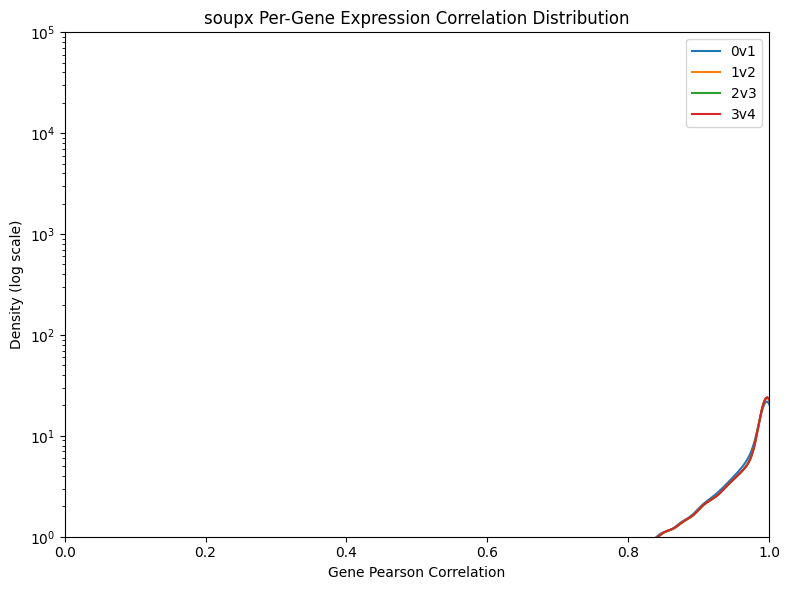

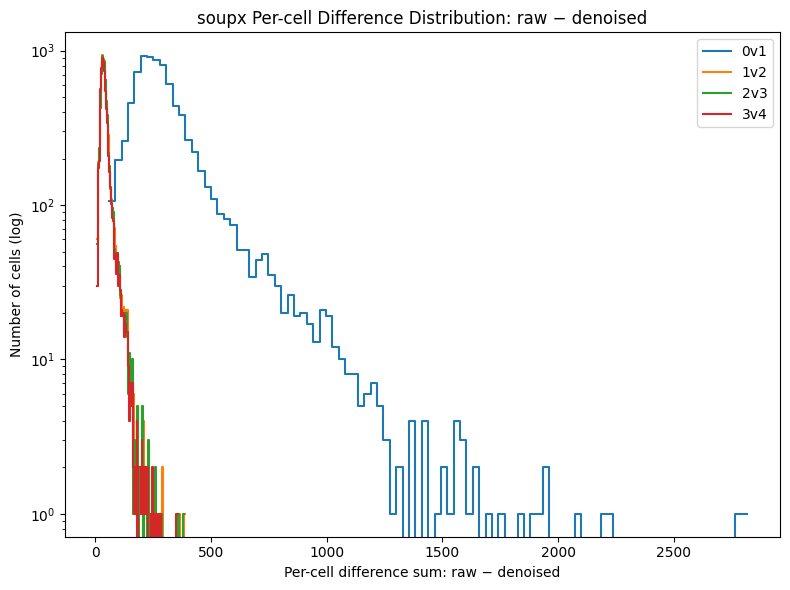

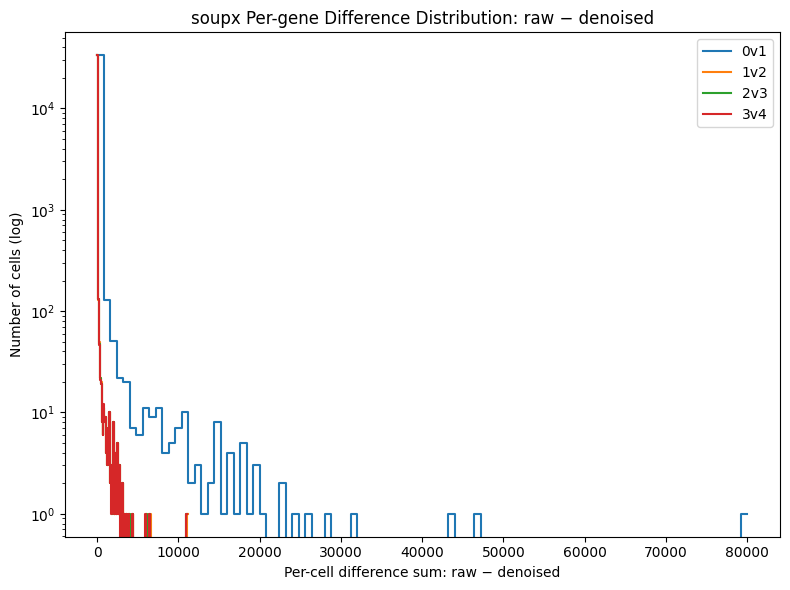

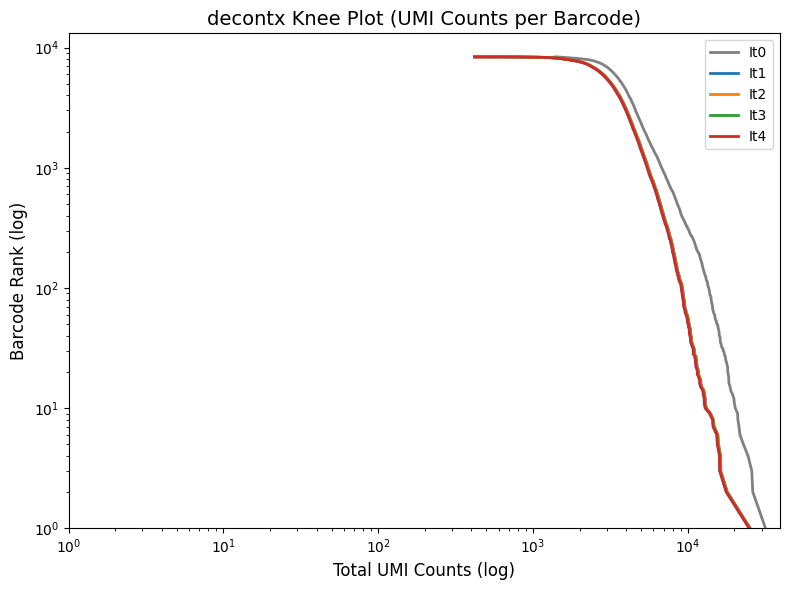

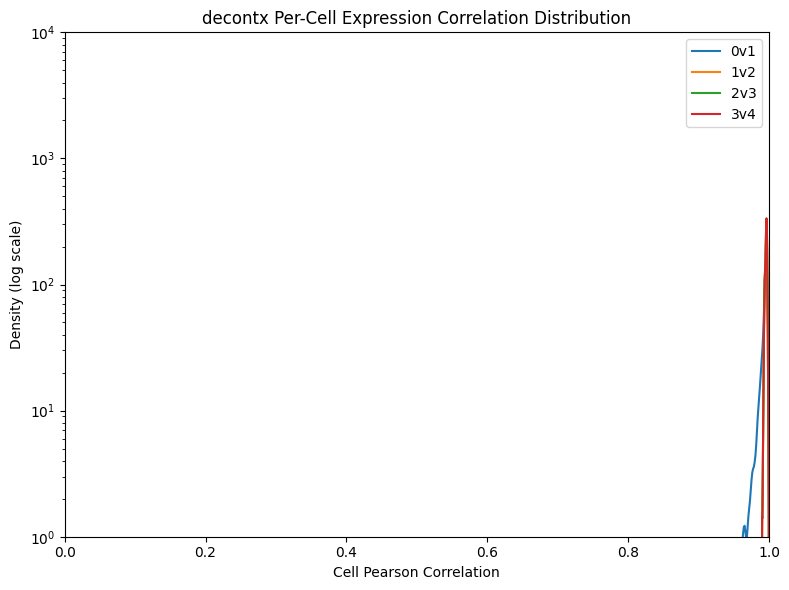

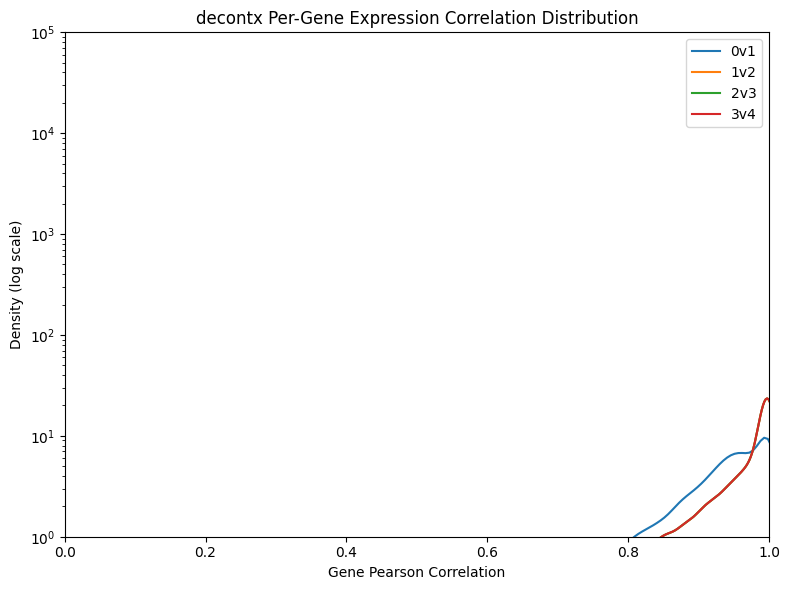

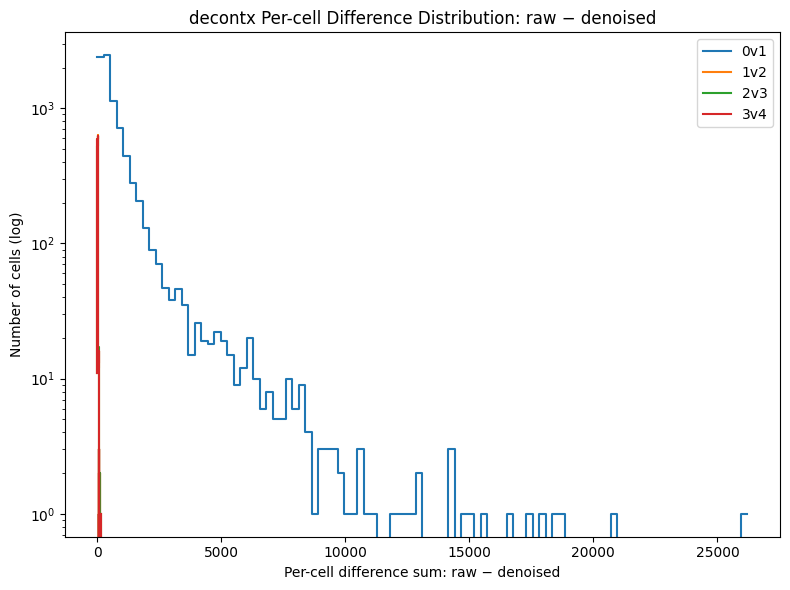

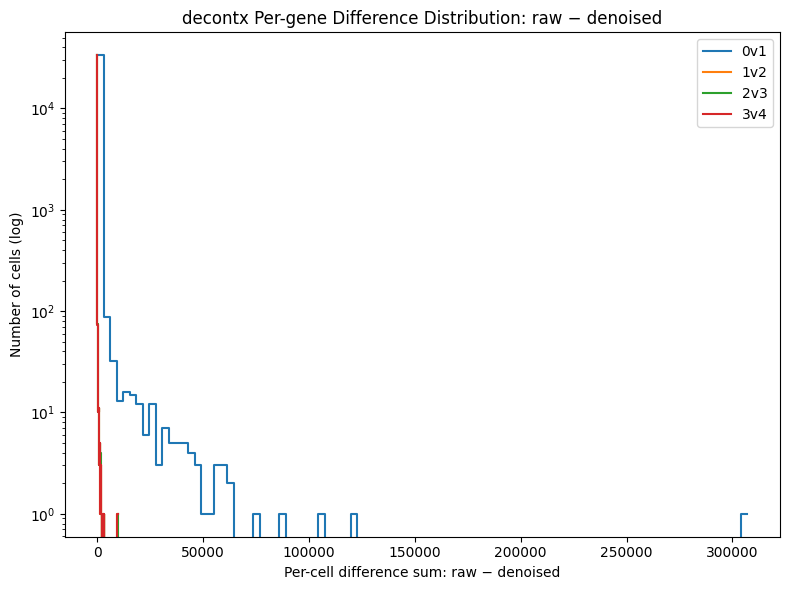

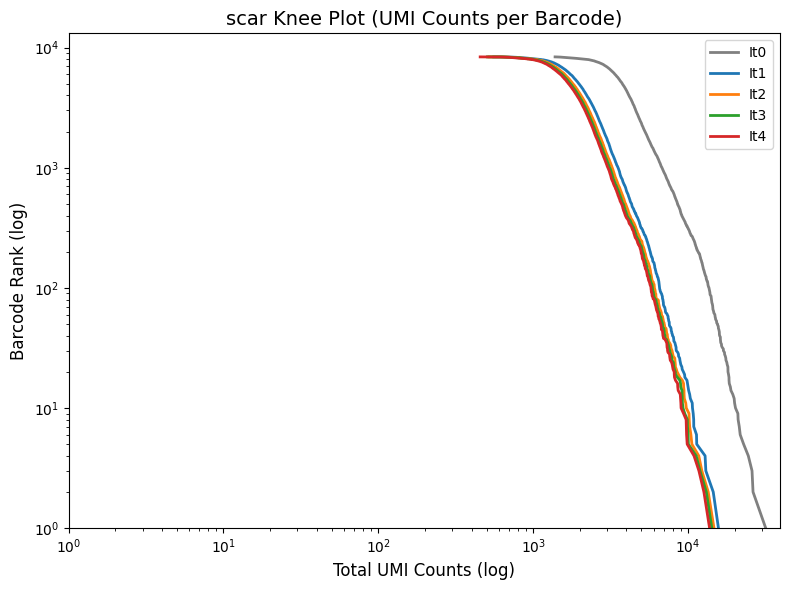

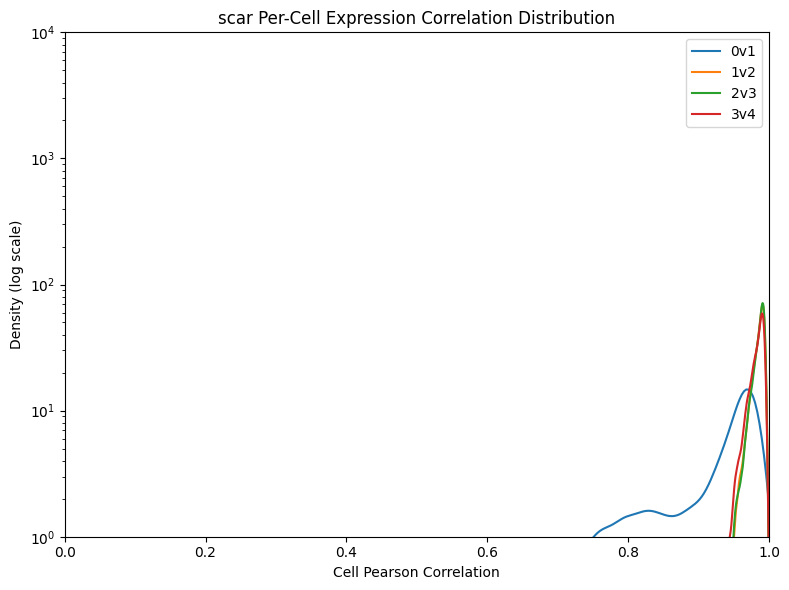

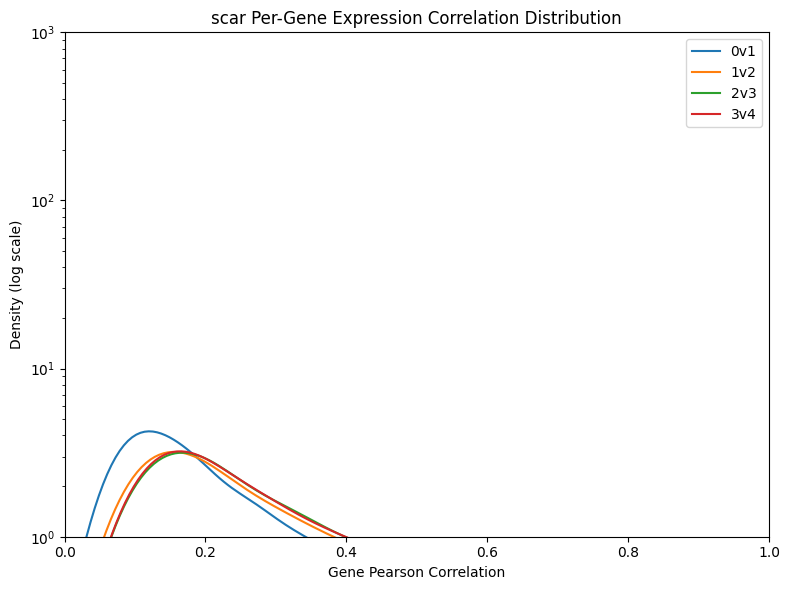

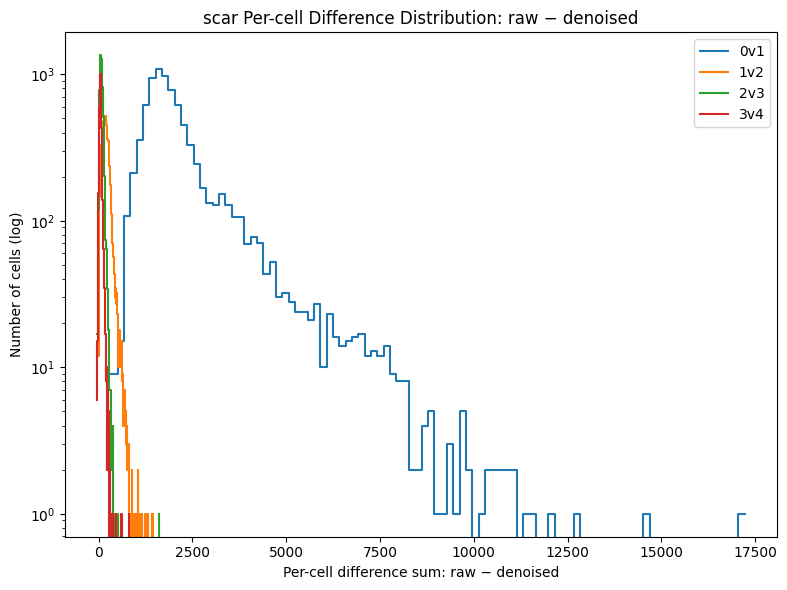

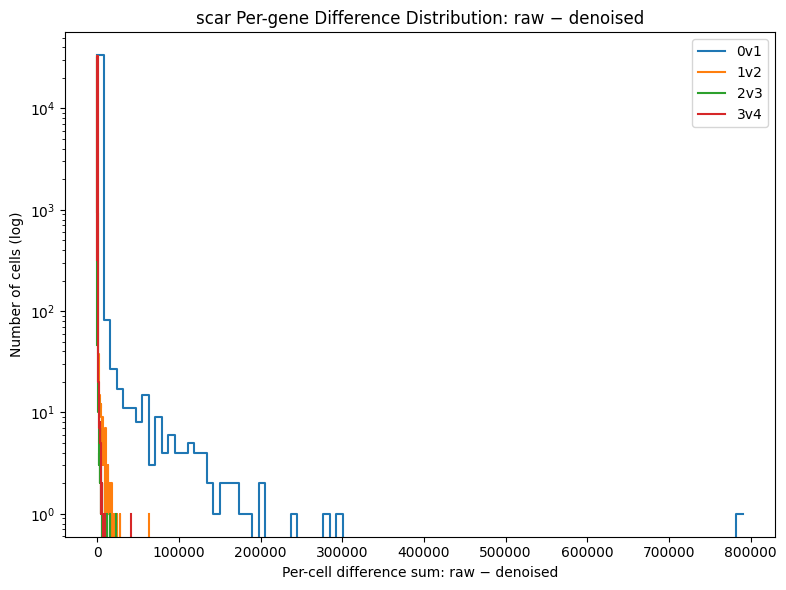

In [ ]:
labels_knee = [f"It{i}" for i in range(iterations+1)]
labels_histograms = [f"{i}v{i+1}" for i in range(iterations)]
for tool in tools:
    if adatas_dict[tool] is None:
        continue

    cs_utils.plot_knee_multi(adatas_dict[tool], labels=labels_knee, title=f"{tool} Knee Plot (UMI Counts per Barcode)", filter_empty=True, transpose=True, out_path=os.path.join(out_dir, f"{tool}_knee_plot_overlay.png"))
    
    cs_utils.plot_per_cell_correlation_multi(adatas_dict[tool][:-1], adatas_dict[tool][1:], labels=labels_histograms, plot_type="cell", title=f"{tool} Per-Cell Expression Correlation Distribution", out_path=os.path.join(out_dir, f"{tool}_per_cell_correlation_overlay.png"))
    cs_utils.plot_per_cell_correlation_multi(adatas_dict[tool][:-1], adatas_dict[tool][1:], labels=labels_histograms, plot_type="gene", title=f"{tool} Per-Gene Expression Correlation Distribution", out_path=os.path.join(out_dir, f"{tool}_per_gene_correlation_overlay.png"))
    
    cs_utils.plot_per_cell_difference_multi(adata_raw_list=adatas_dict[tool][:-1], adata_denoised_list=adatas_dict[tool][1:], labels=labels_histograms, plot_type="cell", title=f"{tool} Per-cell Difference Distribution: raw − denoised", out_path=os.path.join(out_dir, f"{tool}_per_cell_absolute_difference_overlay.png"))
    cs_utils.plot_per_cell_difference_multi(adata_raw_list=adatas_dict[tool][:-1], adata_denoised_list=adatas_dict[tool][1:], labels=labels_histograms, plot_type="gene", title=f"{tool} Per-gene Difference Distribution: raw − denoised", out_path=os.path.join(out_dir, f"{tool}_per_gene_absolute_difference_overlay.png"))

In [15]:
# max_points = 10_000
# for i in range(1, iterations+1):
#     for tool in tools:
#         adatas_tool = adatas_dict[tool]
#         if len(adatas_tool) <= i:
#             continue
#         x_name = f"{tool} Iteration {i-1}" if i > 1 else "Raw expression"
#         y_name = f"{tool} Iteration {i}"

#         cs_utils.plot_matrix_scatterplot(adatas_tool[i-1], adatas_tool[i], scale="log", x_axis=x_name, y_axis=y_name, max_points=max_points, out_path=os.path.join(out_dir, f"{tool}_iteration{i}_expression_scatterplot_{max_points}points.png"), show=True)
#         cs_utils.plot_per_cell_correlation(adatas_tool[i-1], adatas_tool[i], title=f"Cell Pearson Correlation Histogram: {tool} Iteration {i}", out_path=os.path.join(out_dir, f"{tool}_iteration{i}_per_cell_correlation.png"))
#         cs_utils.plot_per_cell_difference(adatas_tool[i-1], adatas_tool[i], tool=tool, out_path=os.path.join(out_dir, f"{tool}_iteration{i}_per_cell_absolute_difference.png"))

## extra plots for cellsweep no empties

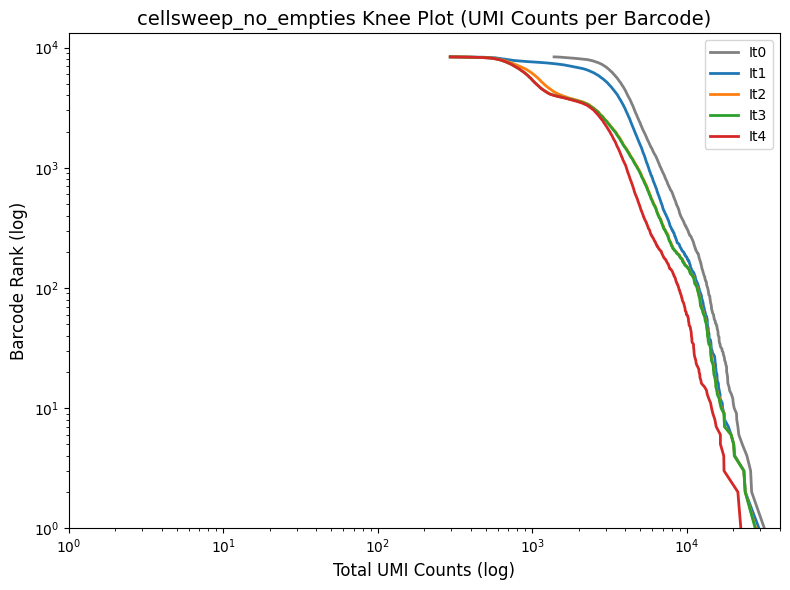

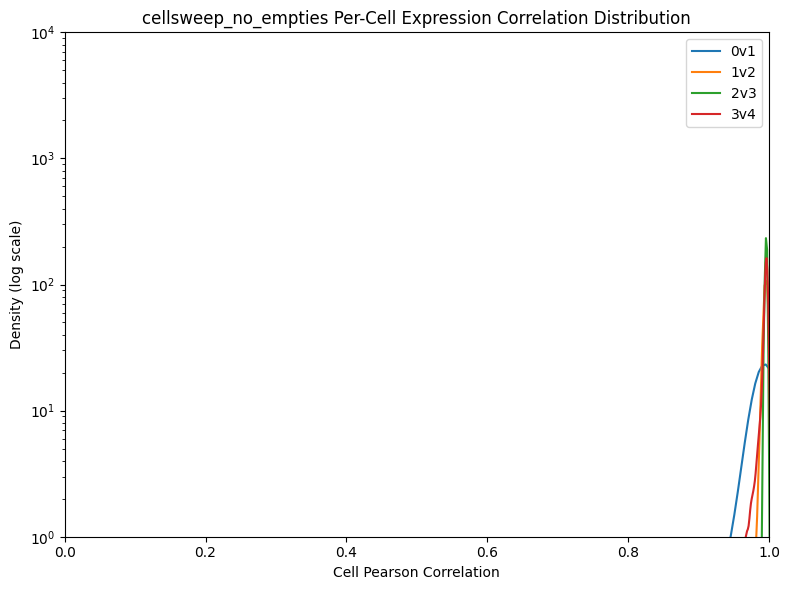

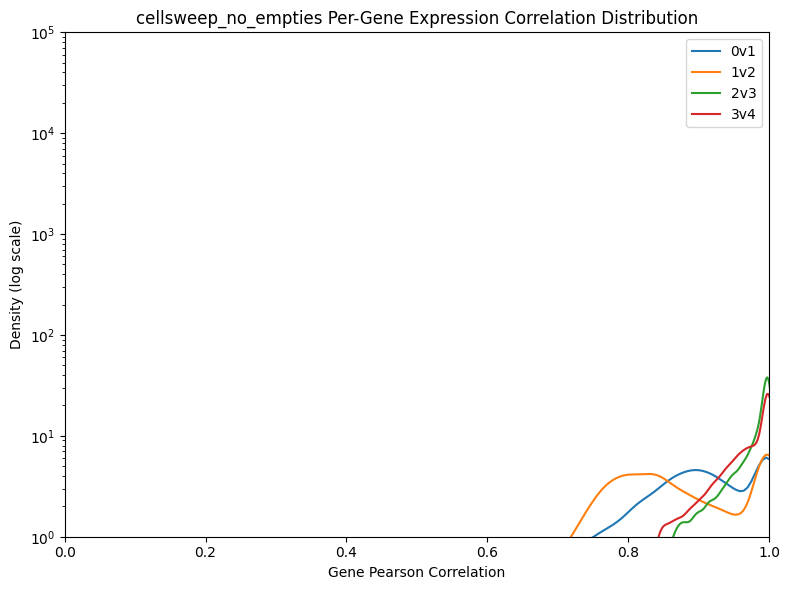

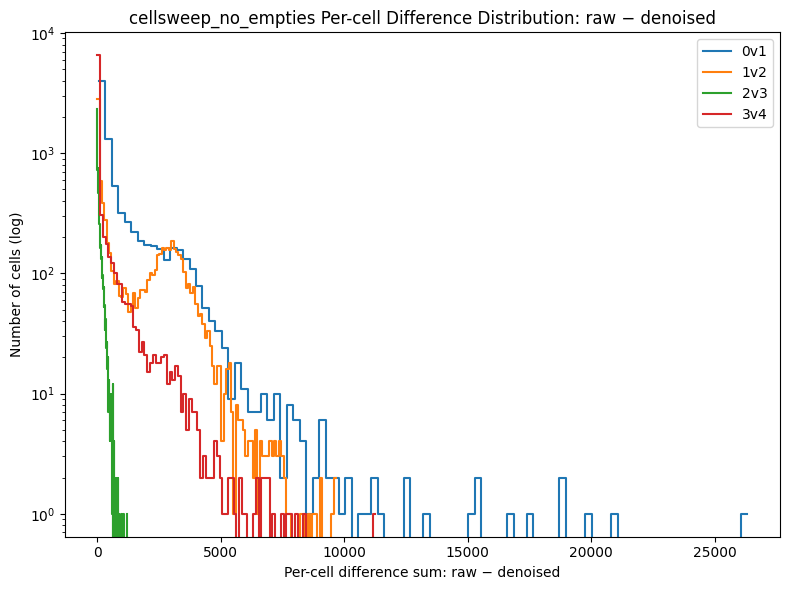

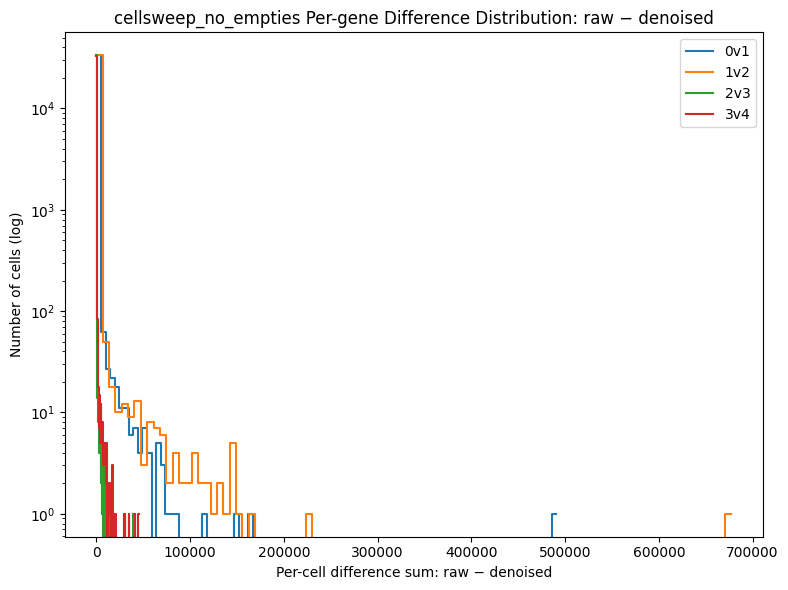

In [9]:
if adatas_cellsweep_no_empties is not None:
    adatas_dict_no_empties = OrderedDict(
        cellsweep=adatas_cellsweep,
        cellsweep_no_empties=adatas_cellsweep_no_empties
    )

    diff_counts = cs_utils.plot_iterative_difference_counts(adatas_dict_no_empties, metric="cells", expected_cells=expected_cells, threshold=100, title="Number of Cells Differing per Iteration", out_path=os.path.join(out_dir, "no_empties_diff_cells.png"))
    diff_counts = cs_utils.plot_iterative_difference_counts(adatas_dict_no_empties, metric="counts", title="Total Count Difference per Iteration", out_path=os.path.join(out_dir, "no_empties_diff_counts.png"))
    diff_counts = cs_utils.plot_iterative_difference_counts(adatas_dict_no_empties, metric="number_of_cells", expected_cells=expected_cells, title="Number of Cells per Iteration", out_path=os.path.join(out_dir, "no_empties_diff_number_of_cells.png"))
    
    tool = "cellsweep_no_empties"

    labels_knee = [f"It{i}" for i in range(iterations+1)]
    labels_histograms = [f"{i}v{i+1}" for i in range(iterations)]
    cs_utils.plot_knee_multi(adatas_cellsweep_no_empties, labels=labels_knee, title=f"{tool} Knee Plot (UMI Counts per Barcode)", filter_empty=True, transpose=True, out_path=os.path.join(out_dir, f"{tool}_knee_plot_overlay.png"))

    cs_utils.plot_per_cell_correlation_multi(adatas_cellsweep_no_empties[:-1], adatas_cellsweep_no_empties[1:], labels=labels_histograms, plot_type="cell", title=f"{tool} Per-Cell Expression Correlation Distribution", out_path=os.path.join(out_dir, f"{tool}_per_cell_correlation_overlay.png"))
    cs_utils.plot_per_cell_correlation_multi(adatas_cellsweep_no_empties[:-1], adatas_cellsweep_no_empties[1:], labels=labels_histograms, plot_type="gene", title=f"{tool} Per-Gene Expression Correlation Distribution", out_path=os.path.join(out_dir, f"{tool}_per_gene_correlation_overlay.png"))

    cs_utils.plot_per_cell_difference_multi(adata_raw_list=adatas_cellsweep_no_empties[:-1], adata_denoised_list=adatas_cellsweep_no_empties[1:], labels=labels_histograms, plot_type="cell", title=f"{tool} Per-cell Difference Distribution: raw − denoised", out_path=os.path.join(out_dir, f"{tool}_per_cell_absolute_difference_overlay.png"))
    cs_utils.plot_per_cell_difference_multi(adata_raw_list=adatas_cellsweep_no_empties[:-1], adata_denoised_list=adatas_cellsweep_no_empties[1:], labels=labels_histograms, plot_type="gene", title=f"{tool} Per-gene Difference Distribution: raw − denoised", out_path=os.path.join(out_dir, f"{tool}_per_gene_absolute_difference_overlay.png"))